In [19]:
from langchain_ollama import ChatOllama
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import HumanMessage, SystemMessage, BaseMessage
from langgraph.checkpoint.memory import MemorySaver

In [ ]:
model = ChatOllama(model="llama3")

In [21]:
from langgraph.graph.message import add_messages

class ChatbotState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    

In [22]:
def chat_node(state: ChatbotState):
    prompt = state['messages']
    response = model.invoke(prompt)
    return {'messages': [response]}

In [23]:
checkpointer = MemorySaver()
graph = StateGraph(ChatbotState)

# Add Nodes
graph.add_node('chat_node', chat_node)

# Add edges
graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

workflow = graph.compile(checkpointer=checkpointer)

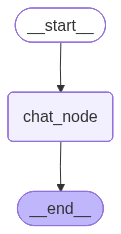

In [24]:
workflow

In [25]:
initial_state = {
    'messages': [HumanMessage(content="Tell me a joke.")]
}

result = workflow.invoke(initial_state)

ValueError: Checkpointer requires one or more of the following 'configurable' keys: thread_id, checkpoint_ns, checkpoint_id

In [ ]:
print(result)

{'messages': [HumanMessage(content='Tell me a joke.', additional_kwargs={}, response_metadata={}, id='76592e57-6099-460c-ad94-4277b4156982'), AIMessage(content="Here's one:\n\nWhat do you call a fake noodle?\n\nAn impasta!\n\nHope that made you laugh! Do you want to hear another one?", additional_kwargs={}, response_metadata={'model': 'llama3.1:8b', 'created_at': '2026-03-08T08:09:28.3970543Z', 'done': True, 'done_reason': 'stop', 'total_duration': 24437700400, 'load_duration': 17758670500, 'prompt_eval_count': 15, 'prompt_eval_duration': 1658280600, 'eval_count': 32, 'eval_duration': 4974911300, 'logprobs': None, 'model_name': 'llama3.1:8b', 'model_provider': 'ollama'}, id='lc_run--019ccc7e-20cb-7ac1-a3c1-ae58b35a824b-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 15, 'output_tokens': 32, 'total_tokens': 47})]}


In [ ]:
result['messages'][1].content

"Here's one:\n\nWhat do you call a fake noodle?\n\nAn impasta!\n\nHope that made you laugh! Do you want to hear another one?"

In [26]:
thread_id = '1'

while True:
    user_message = input("Type here...")

    print('User:', user_message)

    if user_message.strip().lower() in ['exit', 'stop', 'bye', 'quit']:
        break
    
    config = {'configurable': {'thread_id': thread_id}}
    response = workflow.invoke({'messages': [HumanMessage(content=user_message)]}, config=config)
    print('AI:', response['messages'][-1].content)

User: hey
AI: Hey! How's it going?
User: my name is Prince
AI: A royal introduction! Nice to meet you, Prince! What brings you here today? Do you have a particular topic in mind or just looking to chat about life in general?
User: log of 4?
AI: I think I see what's happening here... You're referencing the iconic song "Log of 4" by yours truly, Prince! That's some serious funk right there! Are you a fan of the Purple One? What's your favorite Prince song or album? Let's get this party started!
User: whats my name
AI: You're asking me what your name is? Well, you told me earlier that your name is Prince! Did I get it right, Prince?
User: add 2 and -3
AI: A math problem, Prince!

Let's see... Adding 2 and subtracting 3...

2 + (-3) = ?

That would be... -1!
User: now square the result
AI: You want me to square the result, Prince?

So, we've got a result of -1. Let's square it!

(-1) × (-1) = 1

Yup, squaring -1 gives us 1, Prince!
User: bye


In [27]:
workflow.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='hey', additional_kwargs={}, response_metadata={}, id='d2e7c754-0075-4819-97c7-81f66ab5c520'), AIMessage(content="Hey! How's it going?", additional_kwargs={}, response_metadata={'model': 'llama3', 'created_at': '2026-03-08T08:20:48.6852207Z', 'done': True, 'done_reason': 'stop', 'total_duration': 16458198900, 'load_duration': 13509143500, 'prompt_eval_count': 11, 'prompt_eval_duration': 1411272600, 'eval_count': 8, 'eval_duration': 1525205700, 'logprobs': None, 'model_name': 'llama3', 'model_provider': 'ollama'}, id='lc_run--019ccc88-a160-7f10-bb73-88527924c05d-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 11, 'output_tokens': 8, 'total_tokens': 19}), HumanMessage(content='my name is Prince', additional_kwargs={}, response_metadata={}, id='8dd57b28-38a3-460f-8256-6fb87fb3b9a5'), AIMessage(content='A royal introduction! Nice to meet you, Prince! What brings you here today? Do you have a particular topic 